In [ ]:
import graphviz
!apt install libgraphviz-dev
!pip install pygraphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk librsvg2-common
  libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  librsvg2-common libxcomposite1 libxdot4
0 upgraded, 12 newly installed, 0 to remove and 3 not upgraded.
Need to get 2,496 kB of archives.
After this operation, 7,963 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libgtk2.

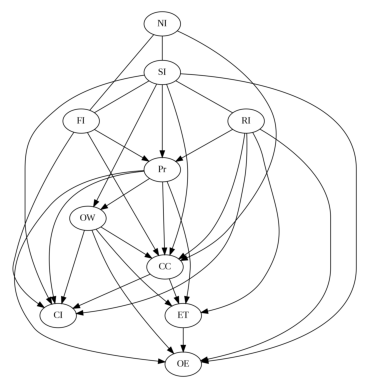

In [ ]:
from causallearn.search.ScoreBased.GES import ges

# default parameters
Record = ges(df)  # df is the dataframe

# Visualization using pydot
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

pyd = GraphUtils.to_pydot(Record['G'], labels=labels)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.axis('off')
plt.imshow(img)
plt.show()

# or save the graph
pyd.write_png('Openstack_GES.png')

## Resources

Number of nodes in fixed_causal_graph_robust: 10
-- Starting SHAP calculation loop for Fixed Graph with RLM ---
  RLM model fit successful for 'ET'.
  KernelExplainer created for 'ET' using RLM. Calculating SHAP values...


  0%|          | 0/25531 [00:00<?, ?it/s]

  SHAP values calculated for 'ET'.
  Added SHAP strengths for 'ET' to dictionary.
  RLM model fit successful for 'CC'.
  KernelExplainer created for 'CC' using RLM. Calculating SHAP values...


  0%|          | 0/25531 [00:00<?, ?it/s]

  SHAP values calculated for 'CC'.
  Added SHAP strengths for 'CC' to dictionary.
  RLM model fit successful for 'Pr'.
  KernelExplainer created for 'Pr' using RLM. Calculating SHAP values...


...

  SHAP values calculated for 'SI'.
  Added SHAP strengths for 'SI' to dictionary.
  RLM model fit successful for 'RI'.
  KernelExplainer created for 'RI' using RLM. Calculating SHAP values...


  0%|          | 0/25531 [00:00<?, ?it/s]

  SHAP values calculated for 'RI'.
  Added SHAP strengths for 'RI' to dictionary.
  RLM model fit successful for 'FI'.
  KernelExplainer created for 'FI' using RLM. Calculating SHAP values...


  0%|          | 0/25531 [00:00<?, ?it/s]

  SHAP values calculated for 'FI'.
  Added SHAP strengths for 'FI' to dictionary.
--- End SHAP calculation loop for Fixed Graph with RLM ---
Calculated RLM SHAP-based edge strengths for Fixed Graph:
{('CC', 'ET'): np.float64(192.0281886843155), ('Pr', 'ET'): np.float64(56.74350318681696), ('OW', 'ET'): np.float64(65.31597373417132), ('RI', 'ET'): np.float64(79.04854993918684), ('Pr', 'CC'): np.float64(0.046418726136345956), ('OW', 'CC'): np.float64(0.010126717521167238), ('NI', 'CC'): np.float64(0.003574961380525683), ('SI', 'CC'): np.float64(0.25383131526300234), ('RI', 'CC'): np.float64(1.245564927191427), ('FI', 'CC'): np.float64(0.24766919281077623), ('SI', 'Pr'): np.float64(0.013815464688977486), ('RI', 'Pr'): np.float64(0.05034972141179592), ('FI', 'Pr'): np.float64(0.01892341297184137), ('CC', 'CI'): np.float64(1.8934092209042785), ('Pr', 'CI'): np.float64(0.14258431699456764), ('OW', 'CI'): np.float64(0.1579537706843558), ('SI', 'CI'): np.float64(0.10346549497645863), ('RI', 'C

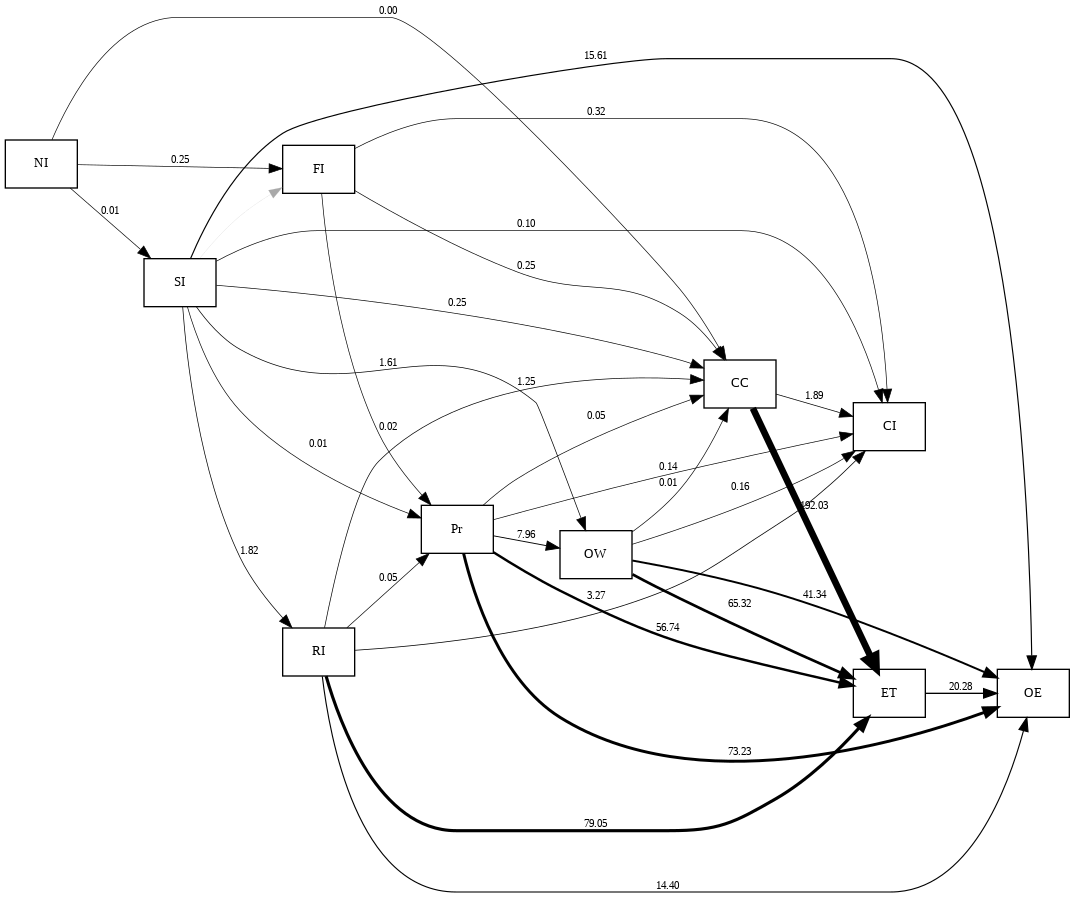

In [ ]:
import shap
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm # For RLM
import pygraphviz as pgv
from sklearn.impute import SimpleImputer
from IPython.display import Image, display


# Use the graph learned by GES
# Assuming 'Record' from the GES execution is available in the kernel state
ges_causal_graph = Record['G']

# Manually convert the causallearn GeneralGraph to a networkx DiGraph
fixed_causal_graph_robust = nx.DiGraph()

# Add nodes with their labels
# Use labels directly as node names in NetworkX graph
for node_label in labels:
    fixed_causal_graph_robust.add_node(node_label)

# Get the ordered list of nodes from the causallearn graph
# The index of each node in this list corresponds to its index in 'labels'
cl_nodes = ges_causal_graph.nodes

# Create a mapping from causallearn Node object to its index
node_to_index_map = {node: i for i, node in enumerate(cl_nodes)}

# Add edges, mapping node objects to their labels
for edge in ges_causal_graph.get_graph_edges():
    # Get the causallearn Node objects involved in the edge
    cl_node1 = edge.node1
    cl_node2 = edge.node2

    # Get their corresponding indices from the map
    node1_index = node_to_index_map[cl_node1]
    node2_index = node_to_index_map[cl_node2]

    # Add edge using the labels
    fixed_causal_graph_robust.add_edge(labels[node1_index], labels[node2_index])

# --- Data Cleaning for SHAP Calculation --- (Copied for consistency)
df_cleaned_for_shap_robust = df.copy()
df_cleaned_for_shap_robust = df_cleaned_for_shap_robust.replace([np.inf, -np.inf], np.nan)
imputer = SimpleImputer(strategy='mean')
numerical_cols_for_imputation_robust = df_cleaned_for_shap_robust.select_dtypes(include=np.number).columns.tolist()
df_cleaned_for_shap_robust[numerical_cols_for_imputation_robust] = imputer.fit_transform(df_cleaned_for_shap_robust[numerical_cols_for_imputation_robust])

print(f"Number of nodes in fixed_causal_graph_robust: {len(fixed_causal_graph_robust.nodes())}")

# Step 2: Compute SHAP values for each edge using Robust Linear Model (RLM)
robust_fixed_graph_shap_strengths = {}
print("-- Starting SHAP calculation loop for Fixed Graph with RLM ---")

for child_node in fixed_causal_graph_robust.nodes():
    if child_node not in df_cleaned_for_shap_robust.columns:
        continue

    parents = list(fixed_causal_graph_robust.predecessors(child_node))
    if not parents:
        continue

    valid_parents = [p for p in parents if p in df_cleaned_for_shap_robust.columns and pd.api.types.is_numeric_dtype(df_cleaned_for_shap_robust[p])]
    if not valid_parents:
        continue

    X_parents = df_cleaned_for_shap_robust[valid_parents]
    y_child = df_cleaned_for_shap_robust[child_node]

    if y_child.nunique() == 1:
        continue

    constant_cols_in_X = [col for col in X_parents.columns if X_parents[col].nunique() == 1]
    if constant_cols_in_X:
        X_parents = X_parents.drop(columns=constant_cols_in_X)
        valid_parents = [p for p in valid_parents if p not in constant_cols_in_X]
        if not valid_parents:
            continue

    X_parents_const = sm.add_constant(X_parents)

    try:
        # Use Robust Linear Model (RLM) with HuberT norm for robust regression
        rlm_model = sm.RLM(y_child, X_parents_const, M=sm.robust.norms.HuberT()).fit()
        print(f"  RLM model fit successful for '{child_node}'.")
    except Exception as e:
        print(f"  Debug: Could not fit RLM model for child '{child_node}' with parents {valid_parents}. Error: {e}. Skipping SHAP calculation.")
        continue

    if len(X_parents_const) > 100:
        background = shap.sample(X_parents_const, 100)
    else:
        background = X_parents_const

    explainer = shap.KernelExplainer(rlm_model.predict, background)
    print(f"  KernelExplainer created for '{child_node}' using RLM. Calculating SHAP values...")

    shap_values_raw_result = explainer.shap_values(X_parents_const, nsamples=100)
    if isinstance(shap_values_raw_result, list):
        shap_values_raw = shap_values_raw_result[0]
    else:
        shap_values_raw = shap_values_raw_result

    print(f"  SHAP values calculated for '{child_node}'.")

    for i, p in enumerate(valid_parents):
        robust_fixed_graph_shap_strengths[(p, child_node)] = np.mean(np.abs(shap_values_raw[:, i + 1]))
    print(f"  Added SHAP strengths for '{child_node}' to dictionary.")

print("--- End SHAP calculation loop for Fixed Graph with RLM ---")
print("Calculated RLM SHAP-based edge strengths for Fixed Graph:")
print(robust_fixed_graph_shap_strengths)

# Step 3: Normalize SHAP strengths for visualization (penwidth) - 0.5 to 5 scale
normalized_robust_fixed_graph_shap_values = {}
if robust_fixed_graph_shap_strengths:
    shap_values_array_robust = np.array(list(robust_fixed_graph_shap_strengths.values())).reshape(-1, 1)
    non_zero_shap_values_robust = shap_values_array_robust[shap_values_array_robust != 0]

    if len(non_zero_shap_values_robust) == 0:
        normalized_robust_fixed_graph_shap_values = {edge: 0.5 for edge in robust_fixed_graph_shap_strengths}
    elif np.max(non_zero_shap_values_robust) - np.min(non_zero_shap_values_robust) < 1e-9:
        normalized_robust_fixed_graph_shap_values = {edge: 0.5 for edge in robust_fixed_graph_shap_strengths if robust_fixed_graph_shap_strengths[edge] != 0}
        for edge in robust_fixed_graph_shap_strengths:
            if robust_fixed_graph_shap_strengths[edge] == 0:
                normalized_robust_fixed_graph_shap_values[edge] = 0.0
    else:
        scaler_robust = MinMaxScaler(feature_range=(0.5, 5))
        temp_shap_values_for_scaling_robust = np.array([v for v in robust_fixed_graph_shap_strengths.values() if v != 0]).reshape(-1, 1)
        if len(temp_shap_values_for_scaling_robust) > 0:
            scaled_values_robust = scaler_robust.fit_transform(temp_shap_values_for_scaling_robust).flatten()
            scaled_idx_robust = 0
            for edge in robust_fixed_graph_shap_strengths:
                if robust_fixed_graph_shap_strengths[edge] != 0:
                    normalized_robust_fixed_graph_shap_values[edge] = scaled_values_robust[scaled_idx_robust]
                    scaled_idx_robust += 1
                else:
                    normalized_robust_fixed_graph_shap_values[edge] = 0.0
        else:
            normalized_robust_fixed_graph_shap_values = {edge: 0.0 for edge in robust_fixed_graph_shap_strengths}
else:
    print("No robust fixed graph SHAP strengths to normalize.")

# Step 4: Visualize the causal graph with Robust SHAP-scaled edge strengths
if fixed_causal_graph_robust.number_of_edges() > 0:
    A_robust = nx.nx_agraph.to_agraph(fixed_causal_graph_robust)

    A_robust.graph_attr['rankdir'] = 'LR'
    A_robust.node_attr['shape'] = 'box'
    A_robust.node_attr['fontsize'] = '10'
    A_robust.edge_attr['fontsize'] = '8'

    for u, v in fixed_causal_graph_robust.edges():
        normalized_strength = normalized_robust_fixed_graph_shap_values.get((u, v), 0.0)
        original_shap = robust_fixed_graph_shap_strengths.get((u, v), 0.0)

        edge = A_robust.get_edge(str(u), str(v))
        if edge:
            if normalized_strength > 0:
                edge.attr['penwidth'] = str(normalized_strength)
                edge.attr['label'] = f'{original_shap:.2f}'
            else:
                edge.attr['penwidth'] = '0.1'
                edge.attr['color'] = 'darkgray'
                edge.attr['label'] = ''
        else:
            print(f"Warning: Edge ({u}, {v}) not found in AGraph when adding attributes.")

    output_filename_robust_shap = 'Causal_Graph_Robust_SHAP_Fixed.png'
    A_robust.draw(output_filename_robust_shap, prog='dot')

    print(f"Causal graph with Robust SHAP-scaled edge strengths saved as '{output_filename_robust_shap}'")

    display(Image(output_filename_robust_shap))
else:
    print("Fixed causal graph has no edges to visualize.")

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# Ensure robust_fixed_graph_shap_strengths is available
if robust_fixed_graph_shap_strengths:
    # Extract values and reshape for MinMaxScaler
    shap_values_array_01 = np.array(list(robust_fixed_graph_shap_strengths.values())).reshape(-1, 1)

    # Initialize MinMaxScaler with a feature_range of (0, 1)
    scaler_01 = MinMaxScaler(feature_range=(0, 1))

    # Fit and transform the SHAP values
    normalized_shap_array_01 = scaler_01.fit_transform(shap_values_array_01)

    # Create a new dictionary for the 0-1 normalized values
    normalized_shap_values_01 = {edge: normalized_shap_array_01[i][0] for i, edge in enumerate(robust_fixed_graph_shap_strengths.keys())}

    print("Normalized SHAP-based edge strengths (0-1 scale):")
    # Convert to DataFrame for better display
    df_normalized_01 = pd.DataFrame(list(normalized_shap_values_01.items()), columns=['Edge', 'Normalized SHAP (0-1)'])['Normalized SHAP (0-1)']
    # Display as markdown table
    print("| Edge             | Normalized SHAP (0-1) |")
    print("|:-----------------|:----------------------|")
    for edge, normalized_val in normalized_shap_values_01.items():
        print(f"| {edge[0]} -> {edge[1]: <12} | {normalized_val: <21.4f} |")
else:
    print("No robust fixed graph SHAP strengths to normalize.")

Normalized SHAP-based edge strengths (0-1 scale):
| Edge             | Normalized SHAP (0-1) |
|:-----------------|:----------------------|
| CC -> ET           | 1.0000                |
| Pr -> ET           | 0.2955                |
| OW -> ET           | 0.3401                |
| RI -> ET           | 0.4117                |
| Pr -> CC           | 0.0002                |
| OW -> CC           | 0.0001                |
| NI -> CC           | 0.0000                |
| SI -> CC           | 0.0013                |
| RI -> CC           | 0.0065                |
| FI -> CC           | 0.0013                |
| SI -> Pr           | 0.0001                |
| RI -> Pr           | 0.0003                |
| FI -> Pr           | 0.0001                |
| CC -> CI           | 0.0099                |
| Pr -> CI           | 0.0007                |
| OW -> CI           | 0.0008                |
| SI -> CI           | 0.0005                |
| RI -> CI           | 0.0170                |
| FI -> CI    

Causal graph with Robust SHAP-scaled edge strengths and normalized (0-1) labels saved as 'Causal_Graph_Robust_SHAP_Openstack.png'


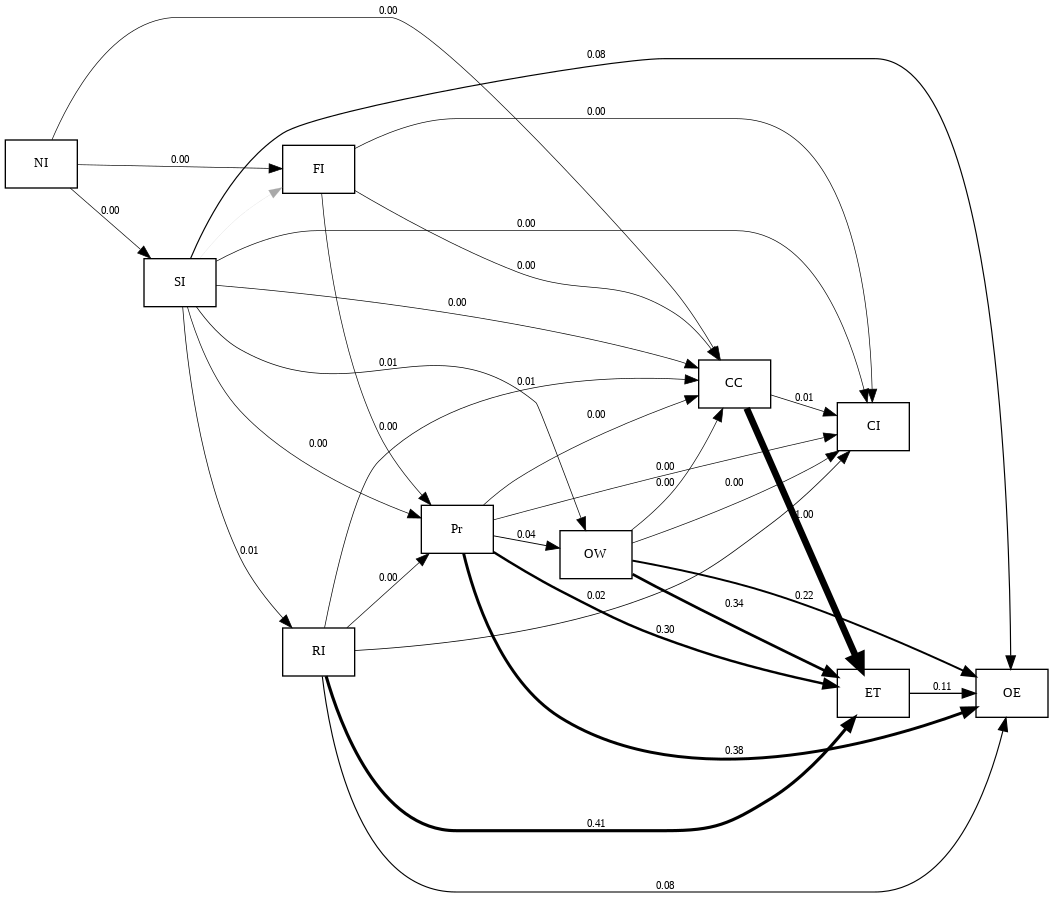

In [ ]:
import networkx as nx
import pygraphviz as pgv
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure fixed_causal_graph_robust, normalized_robust_fixed_graph_shap_values (for penwidth)
# and normalized_shap_values_01 (for labels) are available from previous steps.

if not fixed_causal_graph_robust:
    print("Error: 'fixed_causal_graph_robust' is not defined. Please ensure the causal graph is loaded or created.")
elif not normalized_robust_fixed_graph_shap_values or not normalized_shap_values_01:
    print("Error: Normalized SHAP values are not calculated. Please ensure SHAP calculation and normalization steps were run.")
else:
    try:
        # 1. Convert NetworkX graph to PyGraphviz AGraph
        A = nx.nx_agraph.to_agraph(fixed_causal_graph_robust)

        # 2. Set graphviz attributes for layout
        A.graph_attr['rankdir'] = 'LR'
        A.node_attr['shape'] = 'box'
        A.node_attr['fontsize'] = '10'
        A.edge_attr['fontsize'] = '8'

        # 3. Add edge attributes (penwidth, label) based on normalized SHAP strengths
        for u, v in fixed_causal_graph_robust.edges():
            # Use the 0.5-5 normalized values for penwidth for visual distinction
            penwidth_strength = normalized_robust_fixed_graph_shap_values.get((u, v), 0.0)
            # Use the 0-1 normalized values for the label as requested
            label_strength_01 = normalized_shap_values_01.get((u, v), 0.0)

            edge = A.get_edge(str(u), str(v))
            if edge: # Ensure edge exists before setting attributes
                if penwidth_strength > 0: # Only draw visible edges for non-zero strength
                    edge.attr['penwidth'] = str(penwidth_strength)
                    # Use the 0-1 normalized strength for the label
                    edge.attr['label'] = f'{label_strength_01:.2f}'
                else:
                    # For zero-strength edges, make them very thin and light with no label
                    edge.attr['penwidth'] = '0.1'
                    edge.attr['color'] = 'darkgray'
                    edge.attr['label'] = ''
            else:
                print(f"Warning: Edge ({u}, {v}) not found in AGraph when adding attributes. This might indicate an issue with graph conversion or edge existence.")

        # 4. Save and display the graph
        output_filename_pygv_normalized_labels_01 = 'Causal_Graph_Robust_SHAP_Openstack.png'
        A.draw(output_filename_pygv_normalized_labels_01, prog='dot') # Use 'dot' layout engine

        print(f"Causal graph with Robust SHAP-scaled edge strengths and normalized (0-1) labels saved as '{output_filename_pygv_normalized_labels_01}'")

        display(Image(output_filename_pygv_normalized_labels_01))

    except Exception as e:
        print(f"An error occurred during PyGraphviz rendering: {e}")
        print("Please ensure 'pygraphviz' is correctly installed and its dependencies (Graphviz executables) are met.")